# Finite Markov Decision Processes

Multi-armed bandits evaluate actions without considering a state. A **Markov decision process (MDP)** extends this setting by making the consequences of an action depend on the current state of the environment.

Instead of learning only an action value $q_*(a)$, we learn:

- a **state value** $v_*(s)$: how desirable it is to be in state $s$; and
- an **action value** $q_*(s,a)$: how desirable it is to take action $a$ in state $s$.

These state-dependent values let an agent assign credit to actions whose important consequences may appear many time steps later.

## The Agent-Environment Interface

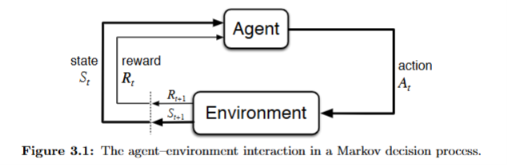

At each time step $t$:

1. the agent observes a state $S_t \in \mathcal{S}$;
2. it selects an action $A_t \in \mathcal{A}(S_t)$;
3. the environment emits a reward $R_{t+1} \in \mathcal{R} \subset \mathbb{R}$; and
4. the environment moves to the next state $S_{t+1}$.

This interaction produces a trajectory

$$S_0, A_0, R_1, S_1, A_1, R_2, S_2, A_2, R_3, \ldots$$

The time indices matter: $A_t$ is chosen in $S_t$, while the resulting reward and next state are $R_{t+1}$ and $S_{t+1}$.

### Dynamics of a finite MDP

In a finite MDP, the state, action, and reward sets contain finitely many elements. The environment dynamics are completely specified by the joint probability

$$p(s',r \mid s,a) \doteq \Pr\{S_{t+1}=s', R_{t+1}=r \mid S_t=s, A_t=a\}.$$

For every state-action pair $(s,a)$, this distribution satisfies

$$\sum_{s'\in\mathcal{S}}\sum_{r\in\mathcal{R}}p(s',r\mid s,a)=1.$$

The **Markov property** says that this distribution depends only on the current state and action. The current state must therefore contain all information from the history that is relevant for predicting the next reward and state.

Several useful quantities can be derived from the joint dynamics.

The **state-transition probability** is

$$p(s'\mid s,a) \doteq \Pr\{S_{t+1}=s'\mid S_t=s,A_t=a\}
=\sum_{r\in\mathcal{R}}p(s',r\mid s,a).$$

The **expected reward** for a state-action pair is

$$r(s,a) \doteq \mathbb{E}[R_{t+1}\mid S_t=s,A_t=a]
=\sum_{r\in\mathcal{R}}r\sum_{s'\in\mathcal{S}}p(s',r\mid s,a).$$

Conditioning additionally on the next state gives

$$r(s,a,s') \doteq \mathbb{E}[R_{t+1}\mid S_t=s,A_t=a,S_{t+1}=s']
=\sum_{r\in\mathcal{R}}r\frac{p(s',r\mid s,a)}{p(s'\mid s,a)},$$

provided that $p(s'\mid s,a)>0$.

## Goals and Rewards

In reinforcement learning, the agent's goal is formalized through a scalar reward signal. The **reward hypothesis** states that any goal can be represented as the maximization of the expected cumulative reward.

The reward should describe **what** the agent should achieve, not **how** it should behave. For example, rewarding a chess agent only for winning expresses the true objective more directly than rewarding it for capturing pieces, which could encourage behavior that collects pieces but loses the game.

## Returns and Episodes

The **return** $G_t$ is the total future reward received after time $t$. For an episodic task that terminates at time $T$,

$$G_t \doteq R_{t+1}+R_{t+2}+\cdots+R_T
=\sum_{k=0}^{T-t-1}R_{t+k+1}.$$

An **episode** is a complete interaction from an initial state to a terminal state. Games, maze traversals, and individual customer interactions are natural episodic tasks. After termination, the environment resets to an initial state for the next episode.

At the terminal state, there are no future rewards, so we define $G_T=0$. Some tasks do not naturally terminate. These are **continuing tasks**: the agent-environment interaction continues indefinitely, so an undiscounted sum of rewards may fail to remain finite.

## Discounted Return

For continuing tasks, future rewards are commonly discounted:

$$G_t \doteq R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\cdots
=\sum_{k=0}^{\infty}\gamma^kR_{t+k+1},$$

where the **discount rate** satisfies $0\leq\gamma\leq1$.

- When $\gamma=0$, the agent is **myopic** and considers only the next reward.
- As $\gamma$ approaches $1$, rewards farther in the future receive more weight.
- When $\gamma<1$ and rewards are bounded, the infinite sum is finite.
- In a finite episodic task, $\gamma=1$ is allowed because the reward sequence ends at $T$.

Discounting can be interpreted mathematically as a way to keep returns bounded and behaviorally as a preference for rewards that arrive sooner.

### Recursive form of the return

The return at one time step is related to the return at the next time step:

$$\begin{aligned}
G_t
&=R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\cdots\\
&=R_{t+1}+\gamma\left(R_{t+2}+\gamma R_{t+3}+\cdots\right)\\
&=R_{t+1}+\gamma G_{t+1}.
\end{aligned}$$

This one-step decomposition is central to reinforcement learning: it connects immediate reward with the value of what follows and is the basis of the Bellman equations.

### Example: a constant reward sequence

If the reward is $+1$ at every time step forever and $\gamma<1$, then the return is the geometric series

$$G_t=1+\gamma+\gamma^2+\gamma^3+\cdots
=\sum_{k=0}^{\infty}\gamma^k
=\frac{1}{1-\gamma}.$$

For example, with $\gamma=0.9$, the return is $1/(1-0.9)=10$. Although the reward stream is infinite, discounting gives it a finite present value.

### Unified notation for episodic and continuing tasks

Both task types can use the same return definition by treating an episodic terminal state as an **absorbing state** that transitions only to itself with reward $0$. Let $T$ be the terminal time for an episodic task and $T=\infty$ for a continuing task. Then

$$G_t \doteq \sum_{k=t+1}^{T}\gamma^{k-t-1}R_k.$$

## Policies and Value Functions

A **policy** $\pi(a\mid s)$ is a probability distribution over the actions available in state $s$. Value functions measure the expected discounted return obtained by following that policy:

$$v_\pi(s) \doteq \mathbb{E}_\pi[G_t\mid S_t=s],$$

$$q_\pi(s,a) \doteq \mathbb{E}_\pi[G_t\mid S_t=s,A_t=a].$$

$v_\pi(s)$ evaluates a state before selecting an action, whereas $q_\pi(s,a)$ evaluates a specific first action followed by policy $\pi$. Terminal states have value $0$.

### Bellman expectation equation

The Bellman equation follows directly from the recursive definition of the return. It expresses the value of a state as the expected immediate reward plus the discounted value of the successor state.

Start from the state-value definition:

$$v_\pi(s)\doteq\mathbb{E}_\pi[G_t\mid S_t=s].$$

Using the recursive return $G_t=R_{t+1}+\gamma G_{t+1}$ gives

$$v_\pi(s)=\mathbb{E}_\pi\!\left[R_{t+1}+\gamma G_{t+1}\mid S_t=s\right].$$

The first uncertainty is the action selected by the policy. Applying the law of total expectation over all $a\in\mathcal{A}(s)$:

$$v_\pi(s)=\sum_a \pi(a\mid s)\,\mathbb{E}_\pi\!\left[R_{t+1}+\gamma G_{t+1}\mid S_t=s,A_t=a\right].$$

After choosing $a$, the environment may produce different rewards $r$ and successor states $s'$. Expanding the conditional expectation over these outcomes:

$$\begin{aligned}
v_\pi(s)
&=\sum_a \pi(a\mid s)\sum_{s',r}p(s',r\mid s,a)\\
&\qquad\cdot\left[r+\gamma\,\mathbb{E}_\pi[G_{t+1}\mid S_t=s,A_t=a,S_{t+1}=s',R_{t+1}=r]\right].
\end{aligned}$$

By the **Markov property**, once the process reaches $S_{t+1}=s'$, the expected future return does not depend on the earlier state, action, or reward. Because the agent continues with the same policy $\pi$,

$$\mathbb{E}_\pi[G_{t+1}\mid S_t=s,A_t=a,S_{t+1}=s',R_{t+1}=r]
=\mathbb{E}_\pi[G_{t+1}\mid S_{t+1}=s']
=v_\pi(s').$$

Substitution produces the Bellman expectation equation:

$$\boxed{v_\pi(s)=\sum_a\pi(a\mid s)\sum_{s',r}p(s',r\mid s,a)\left[r+\gamma v_\pi(s')\right]}.$$

The two sums represent different sources of uncertainty:

1. $\pi(a\mid s)$ weights each action according to how often the agent selects it.
2. $p(s',r\mid s,a)$ weights each possible environment outcome after that action.

The quantity $r+\gamma v_\pi(s')$ is the value of one branch: its immediate reward plus the discounted expected return from its successor. The equation therefore averages the values of **all possible one-step branches**, not merely the rewards associated with the available actions. The discount factor $\gamma$ controls the contribution of future rewards; it is not a probability.

Equivalently, the inner expectation defines the action value

$$q_\pi(s,a)=\sum_{s',r}p(s',r\mid s,a)\left[r+\gamma v_\pi(s')\right],$$

and the outer expectation combines action values under the policy:

$$v_\pi(s)=\sum_a\pi(a\mid s)q_\pi(s,a).$$

This is a recursive consistency equation: the value assigned to $s$ must agree with the values assigned to its possible successors. In code, a Bellman **backup** evaluates these nested sums. Repeating backups propagates reward information backward through the MDP until the values reach the fixed point $v_\pi$.

## Optimal Policies and Optimal Value Functions

A policy $\pi_*$ is **optimal** if it achieves at least as much expected return as every other policy from every state. All optimal policies share the same optimal value functions:

$$v_*(s)\doteq\max_\pi v_\pi(s),$$

$$q_*(s,a)\doteq\max_\pi q_\pi(s,a).$$

$q_*(s,a)$ is the expected return obtained by taking $a$ in $s$ and behaving optimally afterward. Therefore,

$$q_*(s,a)=\sum_{s',r}p(s',r\mid s,a)\left[r+\gamma v_*(s')\right].$$

Under an optimal policy, the agent selects an action with the greatest action value, so

$$v_*(s)=\max_a q_*(s,a).$$

Substituting the expression for $q_*$ gives the **Bellman optimality equation** for state values:

$$\boxed{v_*(s)=\max_a\sum_{s',r}p(s',r\mid s,a)\left[r+\gamma v_*(s')\right]}.$$

The environment outcomes are still averaged according to their probabilities, but the actions are no longer averaged according to a fixed policy. The $\max$ selects the action with the highest expected one-step reward plus discounted optimal successor value.

Using $v_*(s')=\max_{a'}q_*(s',a')$ produces the equivalent Bellman optimality equation for action values:

$$\boxed{q_*(s,a)=\sum_{s',r}p(s',r\mid s,a)\left[r+\gamma\max_{a'}q_*(s',a')\right]}.$$

Once $q_*$ is known, an optimal policy can be recovered greedily by choosing any maximizing action:

$$\pi_*(s)\in\arg\max_a q_*(s,a).$$

Thus, the Bellman **expectation** equation evaluates a given policy, whereas the Bellman **optimality** equation searches for the best policy by replacing the policy-weighted action average with a maximization.

### Why one-step greedy selection is globally optimal

Choosing the maximizing action is only a **one-step operation**, but it is not short-sighted. The terms $v_*(s')$ and $q_*(s',a')$ already summarize the optimal expected return over the entire remaining horizon. Consequently, each action is compared using both its immediate reward and all of its long-term consequences:

$$\text{action score}=\mathbb{E}\!\left[R_{t+1}+\gamma\,\text{optimal future return}\right].$$

This is the principle of optimality: after any first action and transition, the remaining decisions must themselves form an optimal policy from the successor state. A locally greedy choice with respect to the *true optimal value function* is therefore globally optimal. A choice greedy only with respect to immediate reward need not be optimal.

For a finite discounted MDP, the Bellman optimality operator has a unique fixed point. Repeated optimality backups can therefore begin from arbitrary estimates and converge to $v_*$ or $q_*$:

$$V_{k+1}(s)=\max_a\sum_{s',r}p(s',r\mid s,a)\left[r+\gamma V_k(s')\right].$$

The backup considers every action, then averages each action's stochastic outcomes, and finally stores the largest expected value. Repetition propagates information about distant rewards backward through the state space.

There is an important practical distinction between the two optimal value functions:

- With $v_*$, selecting an action requires the environment model $p(s',r\mid s,a)$ to compute a one-step lookahead.
- With $q_*$, the effect of each action is already encoded in its value, so the agent can act with $\arg\max_a q_*(s,a)$ without knowing the transition model.

Multiple actions may attain the same maximum. Any policy that assigns probability only to maximizing actions is optimal, so the optimal value functions are unique even when the optimal policy is not.

### Why exact Bellman solutions are rarely practical

Solving the Bellman optimality equations exactly is equivalent to considering all relevant future possibilities, their probabilities, and their returns. This requires strong assumptions:

1. The transition and reward model $p(s',r\mid s,a)$ is known accurately.
2. The state space is small enough for the required computation and storage.
3. The state representation satisfies the Markov property.

These assumptions often fail in realistic problems. Even with a known model, the number of states can make an exact solution prohibitively expensive; without a model, the Bellman expectations cannot be computed directly.

Most decision-making methods can therefore be interpreted as approximate Bellman solvers:

- **Search methods** expand the transition tree only to a limited depth and use a heuristic value estimate at the leaves.
- **Dynamic programming** performs repeated Bellman backups using a known model.
- **Reinforcement learning** replaces exact expectations with transitions sampled from experience and learns approximate value functions.

The Bellman equation is therefore primarily a target consistency condition: practical algorithms do not usually enumerate the full future tree, but update estimates toward the values that would satisfy the equation.